 # Метрики качества модели классификации


## Метрики для бинарной классификации


Давайте задумаемся, все ли ошибки модели, осуществляющей бинарную классификацию, одинаковы. Предположим, модель решает болен человек (+) или здоров (-). Она может как ошибочно отнести здорового человека к классу больных, так и больного к классу здоровых. Какие будут последствия этих ошибок?

Если здоровый пациент будет классифицирован как больной (`ложно положительный пример`, false positive), это даст
повод для дополнительного обследования, что приведет к некоторым затратам и неудобствам для пациента (и, возможно, к определенному психическому дискомфорту).

Другая возможная ошибка состоит в том,
что больной пациент будет классифицирован как здоровый
(`ложно отрицательный пример`, false negative), не пройдет дополнительные тесты и не получит
лечения. Недиагностированное вовремя заболевание может привести к
серьезным проблемам со здоровьем и очевидно именно таких ошибок мы бы хотели избежать.

В данной задаче мы хотим минимизировать долю ложно
отрицательных примеров, тогда как ложно положительные примеры
можно считать гораздо менее значительной неприятностью.
Вообще, в любых задачах машинного обучения каждый
ложно положительный и ложно отрицательный прогноз редко приводит
к одним и тем же последствиям.


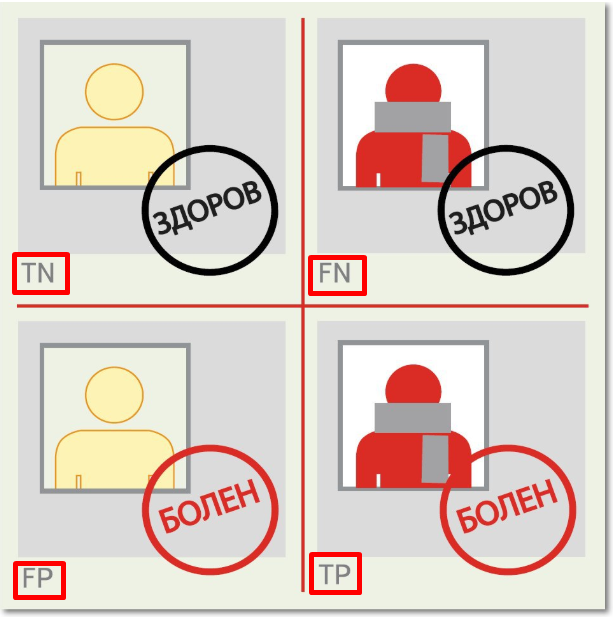


Рассмотрим противоположный пример.

Фармацевтическая компания хотела запустить в производство дорогое лекарство и ей важна окупаемость затрат. Модель машинного обучения относит варианты лекарств к двум классам: стоит запускать в производство (+) или нет (-).  Здесь `ложно положительные примеры` -- это те лекарства, которые мы рекомендовали запустить в производство и ошиблись, в итоге компания понесла большие убытки. И в этом случае минимизировать нужно именно долю таких ошибок.

Типы ошибок играют важную роль, когда один из двух классов встречается гораздо чаще, чем другой (несбалансированный набор данных). Это очень распространенная ситуация на практике.

Представьте, что у нас количество образцов 1, 2 классов относится друг к другу как 9:1. Давайте тогда просто всегда указывать в качестве ответа 1 класс. Доля правильных ответов такого "классификатора" составит аж 90%. Мы можем воспользоваться DummyClassifier, который всегда предсказывает мажоритарный класс, чтобы проиллюстрировать, насколько малоинформативной может быть правильность.

На основе набора данных digits создадим несбалансированный набор данных с пропорциями 9:1, создав два класса «не-девятка» и «девятка».

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
digits = load_digits()

y = digits.target == 9
X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=3)

In [ ]:
import numpy as np
from sklearn.dummy import DummyClassifier

dummy_majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
pred_most_frequent = dummy_majority.predict(X_test)
print("Правильность на тестовом наборе: {:.2f}".format(dummy_majority.score(X_test, y_test)))

Правильность на тестовом наборе: 0.93


У "настоящего" классификатора точность почти такая же!

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=1)

knn.fit(X_train, y_train)
pred_knn = knn.predict(X_test)
print("Правильность на тестовом наборе: {:.3f}".format(knn.score(X_test, y_test)))

Правильность на тестовом наборе: 0.989


### Матрица ошибок

Одним из наиболее развернутых способов, позволяющих оценить
качество бинарной классификации, является использование `матрицы ошибок`. Давайте исследуем прогнозы модели LogisticRegression
с помощью функции confusion_matrix.

In [ ]:
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, pred_knn)
print("Confusion matrix:\n{}".format(confusion))

Confusion matrix:
[[414   3]
 [  2  31]]


Вывод `confusion_matrix` представляет собой массив размером 2x2, где
строки соответствуют фактическим классам, а столбцы соответствуют
спрогнозированным классам. В данном случае речь идет о классах «не-
девятка» и «девятка». Число в каждой ячейке показывает количество
примеров, когда спрогнозированный класс, представленный столбцом,
совпадает или не совпадает с фактическим классом, представленным
строкой.

Элементы главной диагонали `матрицы ошибок` соответствуют
правильным прогнозам (результатам классификации), тогда как
остальные элементы показывают, сколько примеров, относящихся к
одному классу, были ошибочно классифицированы как другой класс.

Здесь 2 девятки были распознаны, как не 9. Три не-9 напротив были классифицированы как 9.

Объявив «девятку» положительным классом, мы можем рассмотреть
элементы матрицы ошибок в терминах ложно положительных (false
positive) и ложно отрицательных (false negative) примеров. Для полноты картины мы назовем правильно
классифицированные положительные примеры истинно
положительными (`true positive`), а правильно классифицированные
отрицательные примеры – истинно отрицательными (`true negative`). Эти
термины, как правило, записывают в сокращенном виде как FP, FN, TP
и TN и приводят к следующей интерпретации матрицы ошибок:

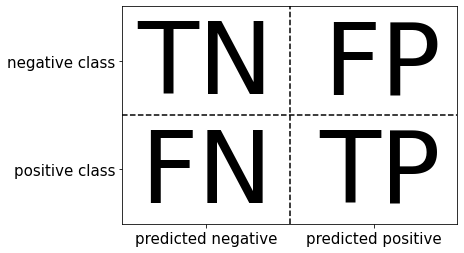

In [ ]:
mglearn.plots.plot_binary_confusion_matrix()

Теперь давайте воспользуемся матрицей ошибок для сравнения ранее
построенных моделей:

In [ ]:
print("Наиболее часто встречающийся класс:")
print(confusion_matrix(y_test, pred_most_frequent))
print("\nkNN:")
print(confusion_matrix(y_test, pred_knn))

Наиболее часто встречающийся класс:
[[417   0]
 [ 33   0]]

kNN:
[[414   3]
 [  2  31]]


Взглянув на матрицу ошибок, становится совершенно ясно, что с моделью `pred_most_frequent` что-то не так, потому что она всегда
предсказывает один и тот же класс.  

Есть несколько способов обобщить информацию, содержащуюся в матрице ошибок.


### Правильность (Accuracy)

– это количество верно классифицированных примеров (TP и TN), поделенное на общее количество примеров (суммируем все элементы матрицы ошибок).

Правильность = $\frac{TP+TN}{TP+TN+FP+FN}$

### Точность (Precision)

– это доля истинно положительных примеров от общего количества предсказанных положительных примеров.

Точность = $\frac{TP}{TP+FP}$

Показывает, сколько из предсказанных
положительных примеров оказались действительно положительными,
используется в качестве показателя качества модели, когда
цель состоит в том, чтобы снизить количество ложно положительных
примеров.

Например, модель предсказывает, будет ли эффективно новое разрабатываемое лекарство. Фармацевтической компании важно убедиться, что препарат действительно работает. В этом случае важно минимизировать число ложно положительных примеров (когда мы скажем, да, работает, а на самом деле нет), т.е. нужно увеличить точность.

### Полнота (Recall)

– это доля истинно положительных
примеров от общего количества фактических положительных примеров.

Полнота = $\frac{TP}{TP+FN}$

Полнота показывает, сколько от общего
числа фактических положительных примеров было предсказано как
положительный класс, используется когда
нам необходимо определить все положительные примеры, то есть, когда
важно снизить количество ложно отрицательных примеров.

Пример диагностики болезни, приведенный ранее, является хорошей
иллюстрацией подобной задачи: важно выявить всех больных пациентов,
при этом, возможно, включив в их число здоровых пациентов. Другие
названия полноты – чувствительность (sensitivity), процент
результативных ответов или хит-рейт (hit rate) и доля истинно
положительных примеров (true positive rate, TPR).

Всегда необходимо найти компромисс между оптимизацией полноты
и оптимизацией точности. Вы легко можете получить идеальную
полноту, спрогнозировав все примеры как положительные.
Однако такое  прогнозирование приведет к
большому количеству ложно положительных примеров, и,
следовательно, точность будет очень низкой.

С другой стороны,
допустим, у вас есть набор данных из 201 примера и вы строите модель,
которая прогнозирует один пример как положительный (и этот пример
действительно относится к положительному классу), а все остальные
примеры относит к отрицательному классу. Предположим, матрица
ошибок выглядит следующим образом.


\begin{array}{cc}
100 & 0 \\
100 & 1
\end{array}

Вычисляем точность и полноту. Точность будет идеальной, а полнота
– очень низкой.

Точность = $\frac{TP}{TP+FP}=\frac{1}{1+0}=1$

Полнота = $\frac{TP}{TP+FN}=\frac{1}{1+100}=0.0099$


Точность и полнота – это лишь две метрики из множества
показателей классификации, получаемых с помощью TP, FP, TN
и FN. Вы можете найти подробное описание метрик в [Википедии](https://en.wikipedia.org/wiki/Sensitivity_and_specificity)

Одним из способов
подытожить точность и полноту является `F-мера` (F-measure), которая представляет собой гармоническое среднее точности и полноты.

### F-мера (F-measure)

F-мера=$2\cdot\frac{точность\cdotполнота}{точность+полнота}$

Давайте применим ее к прогнозам для нашего набора
данных «девятка против остальных».

In [ ]:
from sklearn.metrics import f1_score

print("f1-мера наибольшая частота: {:.2f}".format(f1_score(y_test, pred_most_frequent)))
print("f1-мера kNN: {:.2f}".format(f1_score(y_test, pred_knn)))

f1-мера наибольшая частота: 0.00
f1-мера kNN: 0.93


Похоже, что f-мера действительно дает
более лучшее представление о качестве модели, чем правильность accuracy.
Вместе с тем недостаток f-меры заключается в том, что в отличие от
правильности ее труднее интерпретировать и объяснить.
Если мы хотим получить более развернутый отчет о точности,
полноте и f1-мере, можно воспользоваться удобной функцией
`classification_report`, чтобы вычислить все три метрики сразу и
распечатать их в привлекательном виде:

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_most_frequent, target_names=["not nine", "nine"]))

              precision    recall  f1-score   support

    not nine       0.93      1.00      0.96       417
        nine       0.00      0.00      0.00        33

    accuracy                           0.93       450
   macro avg       0.46      0.50      0.48       450
weighted avg       0.86      0.93      0.89       450



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Отметим, что мы получаем сообщение об ошибке для прогнозов модели most_frequent, поскольку не
было получено ни одного прогноза положительного класса (таким образом, знаменатель в формуле расчета f-меры равен нулю).

Функция `classification_report` печатает отчет, в котором выводятся
показатели `точности`, `полноты` и `f-меры` для отрицательного и
положительного классов. Миноритарный класс «девятка» считается
положительным классом. Значение f-меры для него равно 0. Для
мажоритарного класса «не-девятка» значение f-меры равно 0.96. Кроме
того, полнота для класса «не-девятка» равна 1, поскольку мы
классифицировали все примеры как «не-девятки». Крайний правый
столбец – support, содержит количество примеров данного класса.

В отчете приведено и значение правильности (accuracy).
Также приводятся средние значения метрик, и средние значения
взвешенные по количеству фактических примеров в каждом классе.
Поясним процесс вычисления взвешенного среднего значения на
примере f-метрики. Сначала вычисляем веса отрицательного и
положительного классов. Вес отрицательного класса равен 417/450=0.93.
Вес положительного класса равен 47/450=0.07. Теперь
спрогнозированное значение f-меры для каждого класса умножаем на вес
соответствующего класса, складываем результаты и получаем
взвешенное среднее значение f-меры: 0.93 x 0.93 + 0.07 x 0.00 = 0.86.



## Метрики для мультиклассовой классификации



В основном, все
метрики для мультиклассовой классификации являются производными
от метрик классификации, но при этом усредняются по всем классам. В
мультиклассовой классификации правильность вновь определяется как
доля правильно классифицированных примеров. И опять же, когда
классы не сбалансированы, правильность перестает быть адекватной
метрикой оценки качества. Представьте себе задачу трехклассовой
классификации, когда 85% точек данных принадлежат к классу А, 10% –
к классу В и 5% – к классу C. Что означает среднее значение
правильности 85% применительно к этому набору данных? В целом
результаты мультиклассовой классификации труднее интерпретировать,
чем результаты бинарной классификации. Помимо правильности часто
используемыми инструментами являются матрица ошибок и отчет о
результатах классификации, которые мы рассматривали, разбирая
случай бинарной классификации ранее. Давайте
применим эти два метода оценки для классификации 10 различных
рукописных цифр в наборе данных digits:

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(digits.data, digits.target, random_state=3)
lr = LogisticRegression(max_iter=10000).fit(X_train, y_train)
pred = lr.predict(X_test)
print("Accuracy: {:.3f}".format(accuracy_score(y_test, pred)))
print("Confusion matrix:\n{}".format(confusion_matrix(y_test, pred)))

Accuracy: 0.942
Confusion matrix:
[[55  0  0  0  0  0  0  0  0  0]
 [ 0 45  0  0  0  0  0  0  2  0]
 [ 0  1 44  1  0  0  0  0  0  0]
 [ 0  0  1 46  0  0  0  0  1  0]
 [ 0  6  0  0 47  0  0  1  1  0]
 [ 0  1  0  0  1 35  0  0  0  4]
 [ 0  1  0  0  0  0 34  0  1  0]
 [ 0  0  0  0  0  0  0 49  0  0]
 [ 0  0  0  0  0  0  0  0 40  0]
 [ 0  0  0  0  0  1  0  1  2 29]]


Модель имеет точность 94.2%, что уже говорит нам об очень хорошем
качестве модели. Матрица ошибок дает нам несколько более подробную
информацию. Как и в случае бинарной классификации, каждая строка
соответствует фактической метке класса, а каждый столбец соответствует
спрогнозированной метке класса. Построим более наглядный
график:

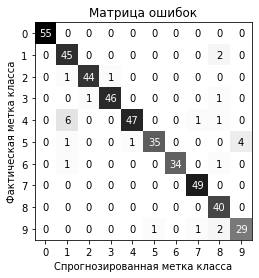

In [ ]:
scores_image = mglearn.tools.heatmap(
    confusion_matrix(y_test, pred), xlabel='Спрогнозированная метка класса',
    ylabel='Фактическая метка класса', xticklabels=digits.target_names,
    yticklabels=digits.target_names, cmap=plt.cm.gray_r, fmt="%d")
plt.title("Матрица ошибок")
plt.gca().invert_yaxis()

Фактическое количество примеров, относящихся к первому классу
(цифре 0), равно 55 и все эти примеры были классифицированы как
 0 (то есть ложно отрицательные примеры для класса 0
отсутствуют). Об этом говорит тот факт, что все остальные элементы
первой строки матрицы ошибок имеют нулевые значения. Кроме того, ни
одна из остальных цифр не была ошибочно классифицирована как 0,
поскольку все остальные элементы первого столбца имеют нулевые
значения (то есть ложно положительные примеры для класса 0
отсутствуют). Однако некоторые цифры были спутаны с остальными,
например, цифра 2 (третья строка), два раза была классифицирована как 1 и 3.

С помощью функции `classification_report` мы можем вычислить
точность, полноту и f-меру для каждого класса:

In [ ]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       0.83      0.96      0.89        47
           2       0.98      0.96      0.97        46
           3       0.98      0.96      0.97        48
           4       0.98      0.85      0.91        55
           5       0.97      0.85      0.91        41
           6       1.00      0.94      0.97        36
           7       0.96      1.00      0.98        49
           8       0.85      1.00      0.92        40
           9       0.88      0.88      0.88        33

    accuracy                           0.94       450
   macro avg       0.94      0.94      0.94       450
weighted avg       0.95      0.94      0.94       450



Неудивительно, что для класса 0 получены идеальные значения
точности и полноты, равные 1, поскольку все примеры
классифицированы правильно. Для класса 6 получена идеальная
точность, поскольку отсутствуют ложно положительные примеры (ни
один из остальных классов не был ошибочно классифицирован как класс
6), тогда как для класса 7 получена идеальная полнота, поскольку
отсутствуют ложно отрицательные примеры.